In [1]:
!pip uninstall -y numpy
!pip install numpy==1.26.4
!pip install torch==2.2.1
!pip install transformers==4.38.2
!pip install datasets==2.18.0
!pip install accelerate scikit-learn matplotlib

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.2.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.36.2 which is incompatible.
transformers 5.2.0 requires tokenizers<=0.23.0,>=0.22.0, but you have tokenizers 0.15.2 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires num

  Using cached torch-2.2.1-cp312-cp312-manylinux1_x86_64.whl.metadata (26 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.19.3-py3-none-manylinux1_x86_64.whl.m

In [2]:
import os, math, time, random
import numpy as np
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

MODEL_NAMES = [
    "sentence-transformers/all-MiniLM-L6-v2",
    "sentence-transformers/paraphrase-MiniLM-L3-v2",
    "sentence-transformers/all-mpnet-base-v2",
]

Device: cuda


In [3]:
ds = load_dataset("ag_news")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [4]:
N = 3000
texts = ds["train"]["text"][:N]
labels = np.array(ds["train"]["label"][:N], dtype=np.int64)

print("Loaded:", len(texts), "samples")

Loaded: 3000 samples


In [5]:
def mean_pooling(model_output, attention_mask):
    # model_output[0] is last_hidden_state: [B, T, H]
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = (token_embeddings * input_mask_expanded).sum(dim=1)
    sum_mask = input_mask_expanded.sum(dim=1).clamp(min=1e-9)
    return sum_embeddings / sum_mask


# compute embeddings in batch
@torch.no_grad()
def embed_texts(model_name, texts, batch_size=64, max_length=128):
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModel.from_pretrained(model_name)
    model.to(device)
    model.eval()

    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        out = model(**enc)
        emb = mean_pooling(out, enc["attention_mask"])
        emb = torch.nn.functional.normalize(emb, p=2, dim=1)  # L2 normalize for geometry comparability
        all_embs.append(emb.detach().cpu())

    X = torch.cat(all_embs, dim=0).numpy().astype(np.float64)  # float64 for stable eig
    return X

In [6]:

# Spectral metrics

def covariance_spectrum(X):
    """
    X: [n, d] embeddings
    returns eigenvalues of covariance matrix (descending), centered covariance.
    """
    Xc = X - X.mean(axis=0, keepdims=True)
    n = Xc.shape[0]

    Cov = (Xc.T @ Xc) / float(n)

    evals = np.linalg.eigvalsh(Cov)
    evals = np.maximum(evals, 0.0)
    evals = np.sort(evals)[::-1]
    return evals

def effective_rank(evals, eps=1e-12):
    s = evals.sum()
    if s < eps:
        return 0.0
    p = evals / s
    p = np.clip(p, eps, 1.0)
    H = -np.sum(p * np.log(p))
    return float(np.exp(H))

def spectral_entropy(evals, eps=1e-12):
    s = evals.sum()
    if s < eps:
        return 0.0
    p = evals / s
    p = np.clip(p, eps, 1.0)
    return float(-np.sum(p * np.log(p)))

def anisotropy_ratio(evals, eps=1e-12):

    mean = float(np.mean(evals) + eps)
    return float(evals[0] / mean)



# Bootstrap CIs

def bootstrap_ci(metric_fn, X, n_boot=200, sample_frac=0.7, seed=42):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    m = int(n * sample_frac)
    vals = []
    for _ in range(n_boot):
        idx = rng.choice(n, size=m, replace=True)
        vals.append(metric_fn(X[idx]))
    vals = np.array(vals, dtype=np.float64)
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return float(vals.mean()), float(lo), float(hi)

# wrappers for bootstrap
def metric_bundle(X):
    evals = covariance_spectrum(X)
    return {
        "erank": effective_rank(evals),
        "sentropy": spectral_entropy(evals),
        "anisotropy": anisotropy_ratio(evals),
        "top10_eigs": evals[:10].copy(),
        "evals": evals,
    }


# Downstream proxy: fast linear probe
def linear_probe_acc(X, y, seed=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    clf = LogisticRegression(
        max_iter=2000,
        n_jobs=-1,
        verbose=0
    )
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    return float(accuracy_score(y_test, pred))


In [7]:

# Run experiments

results = {}

for model_name in MODEL_NAMES:
    print("\n==============================")
    print("Model:", model_name)
    t0 = time.time()

    X = embed_texts(model_name, texts, batch_size=64 if device=="cuda" else 16, max_length=128)
    print("Embeddings shape:", X.shape)

    # main metrics
    mb = metric_bundle(X)

    # bootstrap CI for key metrics
    er_mean, er_lo, er_hi = bootstrap_ci(lambda Z: metric_bundle(Z)["erank"], X, n_boot=200, sample_frac=0.7, seed=SEED)
    se_mean, se_lo, se_hi = bootstrap_ci(lambda Z: metric_bundle(Z)["sentropy"], X, n_boot=200, sample_frac=0.7, seed=SEED)
    an_mean, an_lo, an_hi = bootstrap_ci(lambda Z: metric_bundle(Z)["anisotropy"], X, n_boot=200, sample_frac=0.7, seed=SEED)

    # linear probe
    acc = linear_probe_acc(X, labels, seed=SEED)

    results[model_name] = {
        "X": X,
        "evals": mb["evals"],
        "effective_rank": mb["erank"],
        "spectral_entropy": mb["sentropy"],
        "anisotropy": mb["anisotropy"],
        "erank_ci": (er_mean, er_lo, er_hi),
        "sentropy_ci": (se_mean, se_lo, se_hi),
        "anisotropy_ci": (an_mean, an_lo, an_hi),
        "linear_probe_acc": acc,
        "time_sec": time.time() - t0
    }

    print(f"Effective rank: {mb['erank']:.2f} | bootstrap mean {er_mean:.2f} [{er_lo:.2f}, {er_hi:.2f}]")
    print(f"Spectral entropy: {mb['sentropy']:.2f} | bootstrap mean {se_mean:.2f} [{se_lo:.2f}, {se_hi:.2f}]")
    print(f"Anisotropy ratio: {mb['anisotropy']:.2f} | bootstrap mean {an_mean:.2f} [{an_lo:.2f}, {an_hi:.2f}]")
    print(f"Linear probe acc (AG News): {acc:.4f}")
    print(f"Time: {results[model_name]['time_sec']:.1f}s")


Model: sentence-transformers/all-MiniLM-L6-v2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Embeddings shape: (3000, 768)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Effective rank: 205.36 | bootstrap mean 191.17 [188.52, 193.78]
Spectral entropy: 5.32 | bootstrap mean 5.25 [5.24, 5.27]
Anisotropy ratio: 34.35 | bootstrap mean 34.89 [32.98, 36.75]
Linear probe acc (AG News): 0.8950
Time: 97.6s


In [8]:

# Compare results

print("\n\n==============================")
print("Summary")
print("==============================")
header = f"{'Model':55s} | {'erank':>8s} | {'sentropy':>9s} | {'anisotropy':>10s} | {'probe_acc':>9s} | {'sec':>6s}"
print(header)
print("-"*len(header))

for m in MODEL_NAMES:
    r = results[m]
    print(f"{m:55s} | {r['effective_rank']:8.2f} | {r['spectral_entropy']:9.2f} | {r['anisotropy']:10.2f} | {r['linear_probe_acc']:9.4f} | {r['time_sec']:6.1f}")




Summary
Model                                                   |    erank |  sentropy | anisotropy | probe_acc |    sec
----------------------------------------------------------------------------------------------------------------
sentence-transformers/all-MiniLM-L6-v2                  |   167.84 |      5.12 |      19.72 |    0.8767 |   25.3
sentence-transformers/paraphrase-MiniLM-L3-v2           |   143.28 |      4.96 |      16.42 |    0.8550 |   23.5
sentence-transformers/all-mpnet-base-v2                 |   205.36 |      5.32 |      34.35 |    0.8950 |   97.6


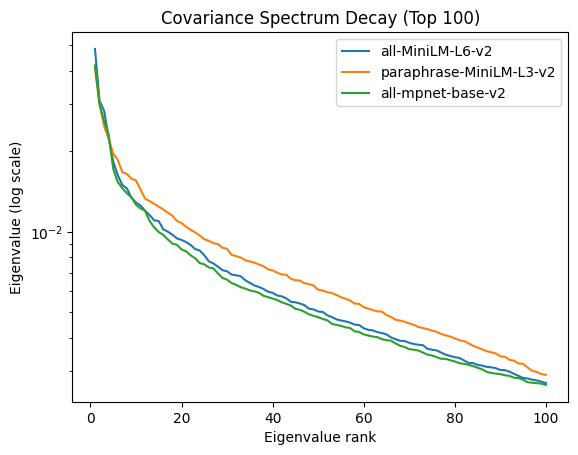

In [9]:

# eigenvalue decay (top 100)

plt.figure()
for m in MODEL_NAMES:
    evals = results[m]["evals"]
    k = min(100, len(evals))
    plt.plot(np.arange(1, k+1), evals[:k], label=m.split("/")[-1])
plt.yscale("log")
plt.xlabel("Eigenvalue rank")
plt.ylabel("Eigenvalue (log scale)")
plt.title("Covariance Spectrum Decay (Top 100)")
plt.legend()
plt.show()

In [10]:

# Correlation: geometry vs accuracy (n=3)

eranks = np.array([results[m]["effective_rank"] for m in MODEL_NAMES])
anis = np.array([results[m]["anisotropy"] for m in MODEL_NAMES])
accs = np.array([results[m]["linear_probe_acc"] for m in MODEL_NAMES])

def pearson(a,b):
    a = a - a.mean()
    b = b - b.mean()
    return float((a*b).sum() / (np.sqrt((a*a).sum())*np.sqrt((b*b).sum()) + 1e-12))

print("\nCorrelation (illustrative, only 3 points):")
print("Pearson(effective_rank, acc) =", pearson(eranks, accs))
print("Pearson(anisotropy, acc)    =", pearson(anis, accs))


Correlation (illustrative, only 3 points):
Pearson(effective_rank, acc) = 0.9859127031666939
Pearson(anisotropy, acc)    = 0.9218470783115608
